In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

import joblib

In [2]:
df = pd.read_csv("Breast Cancer Dataset.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.shape

(569, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df=df.drop(["Unnamed: 32","id"], axis = 1)

In [7]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [8]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

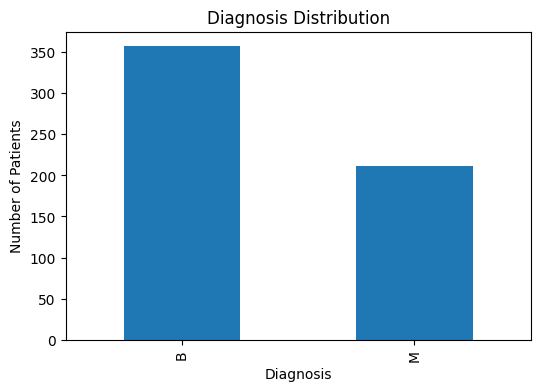

In [11]:
plt.figure(figsize=(6, 4))

df['diagnosis'].value_counts().plot(kind='bar')

plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.title("Diagnosis Distribution")

plt.show()

In [12]:
df['diagnosis'] = df['diagnosis'].map({
    'M': 1,
    'B': 0
})

In [13]:
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [14]:
df = df.drop(columns=['id'])

KeyError: "['id'] not found in axis"

In [15]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
X = df.drop(columns=['diagnosis'])

y = df['diagnosis']

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


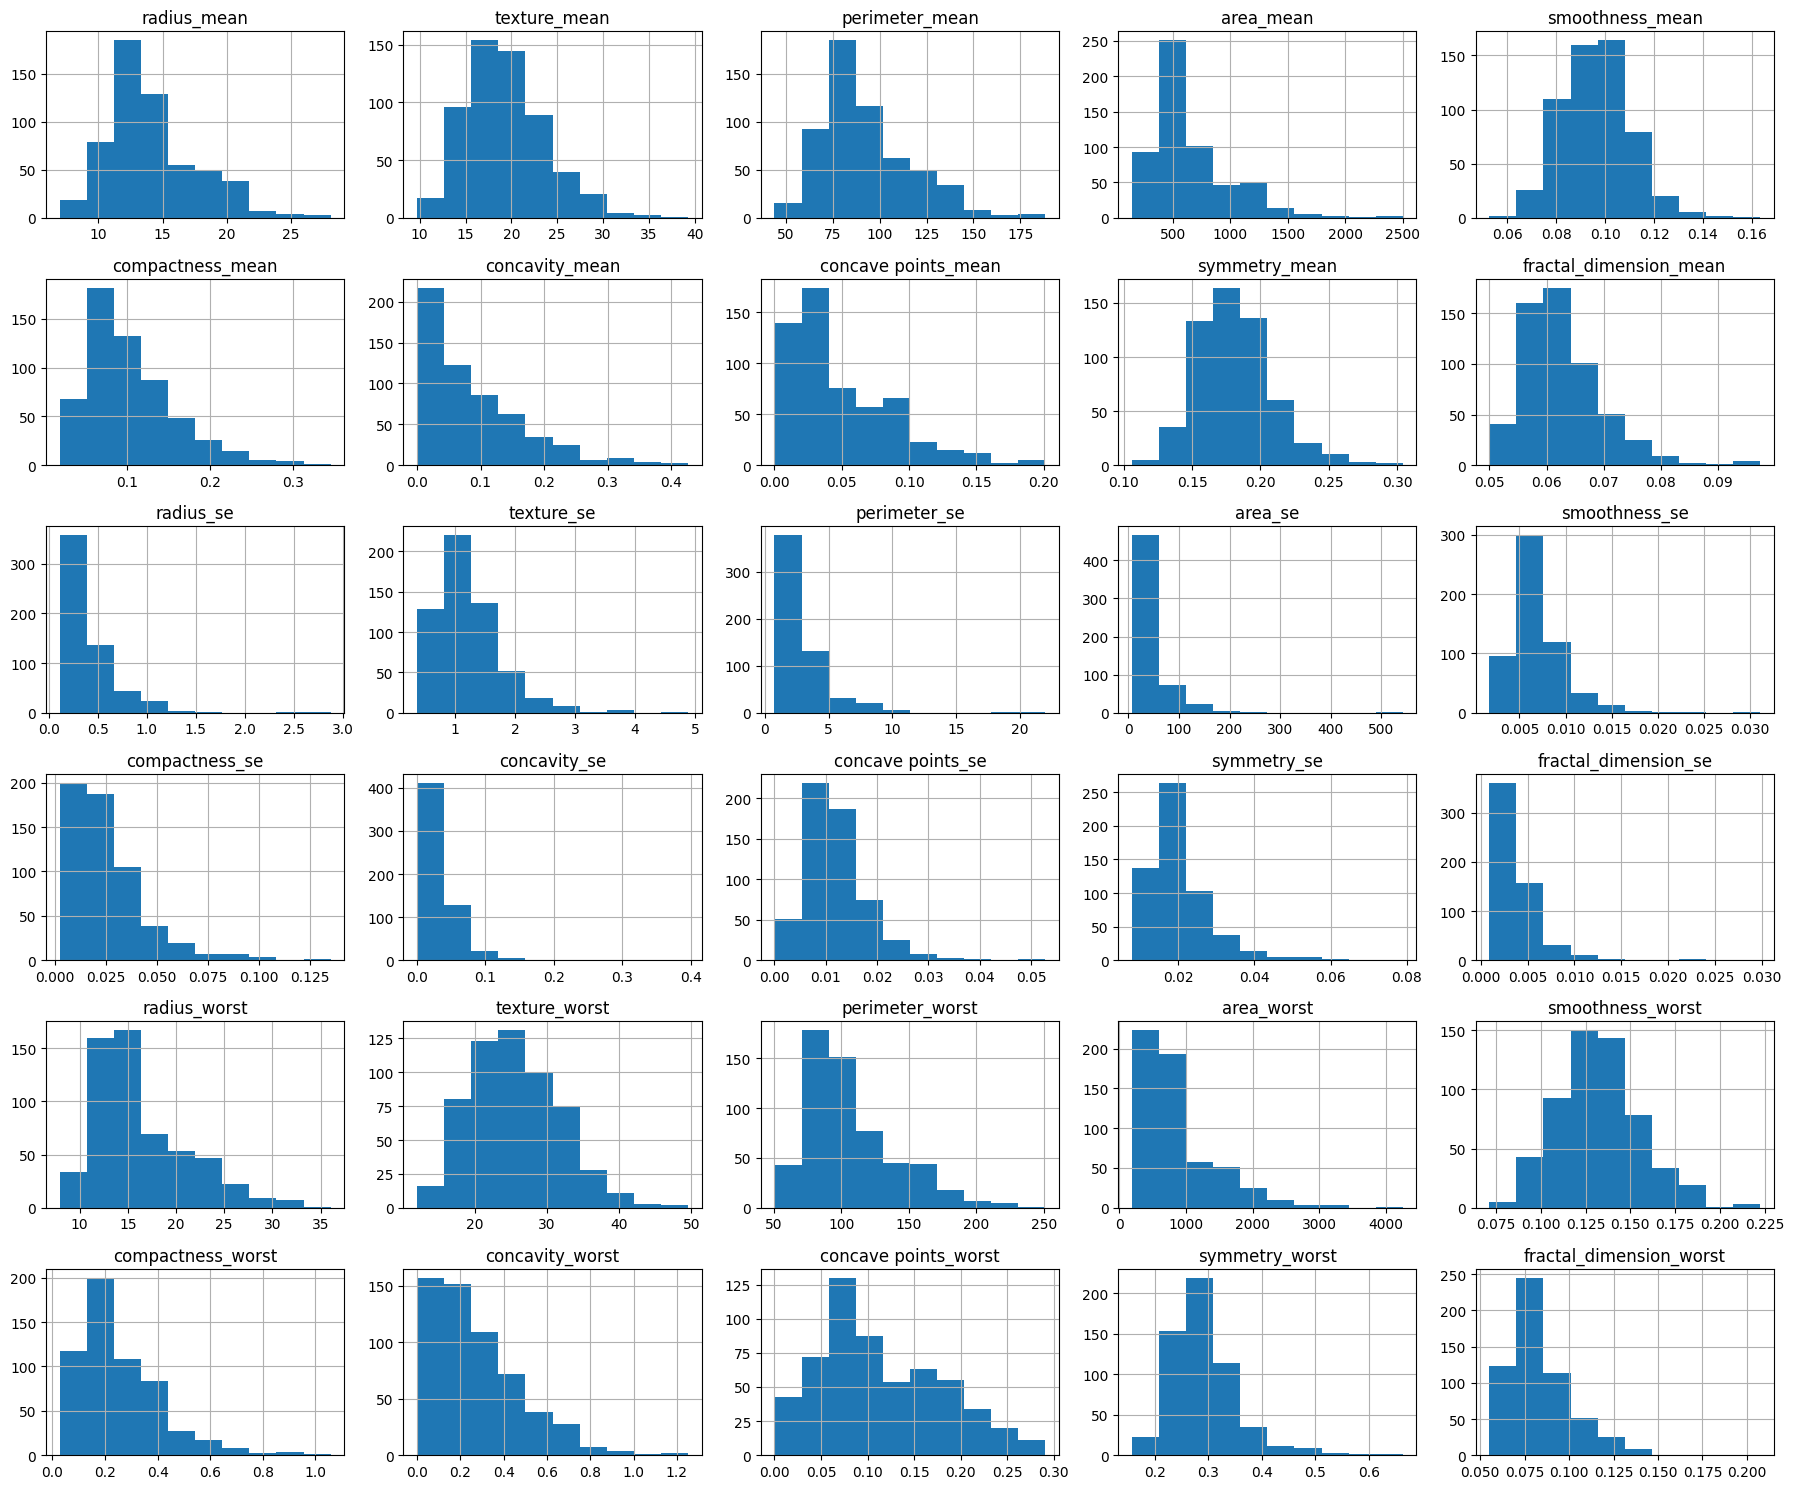

In [18]:
X.hist(figsize=(18, 15))

plt.tight_layout()
plt.show()

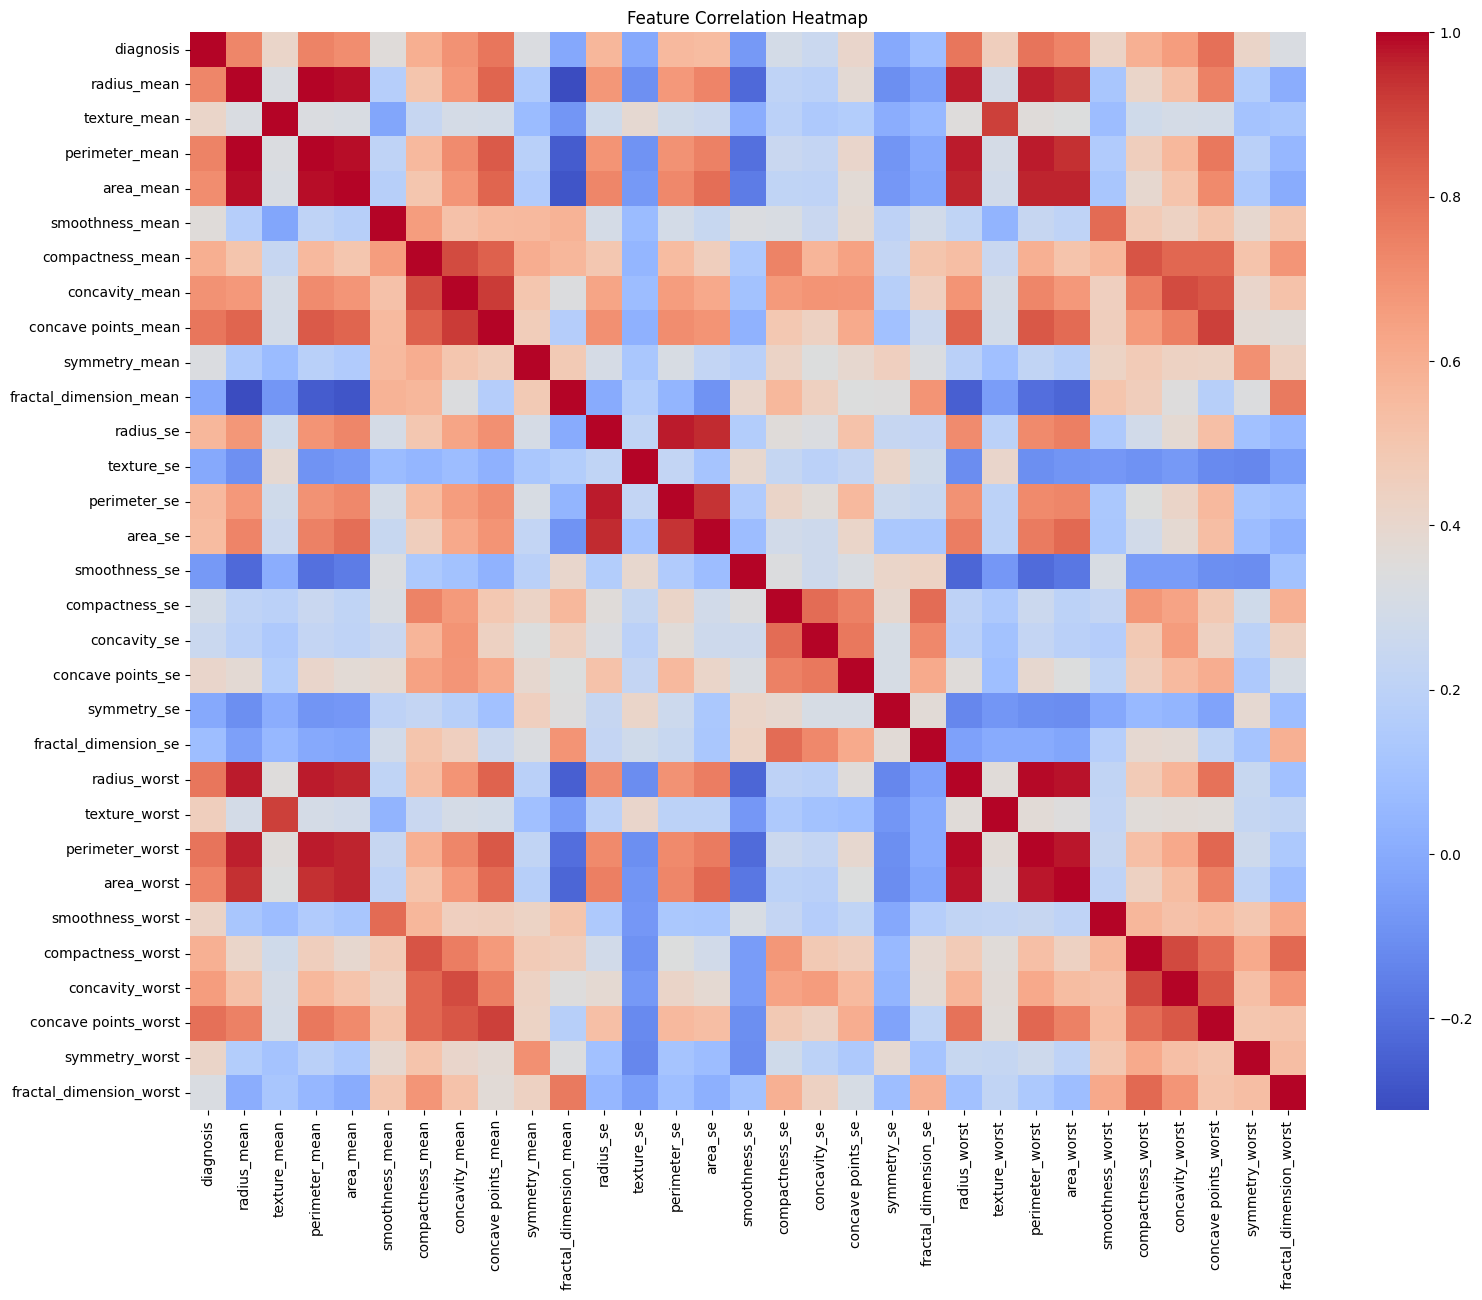

In [19]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [23]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(probability=True),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Naive Bayes":
        GaussianNB(),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42)
}

In [26]:
results = []

for name, model in models.items():

    # Scaling is useful for most algorithms
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

In [27]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220
1,KNN,0.956140,0.974359,0.904762,0.938272
2,SVM,0.973684,1.000000,0.928571,0.962963
3,Decision Tree,0.929825,0.904762,0.904762,0.904762
4,Random Forest,0.973684,1.000000,0.928571,0.962963
5,Naive Bayes,0.921053,0.923077,0.857143,0.888889
6,Gradient Boosting,0.964912,1.000000,0.904762,0.950000


In [28]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,SVM,0.973684,1.000000,0.928571,0.962963
4,Random Forest,0.973684,1.000000,0.928571,0.962963
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220
6,Gradient Boosting,0.964912,1.000000,0.904762,0.950000
1,KNN,0.956140,0.974359,0.904762,0.938272
3,Decision Tree,0.929825,0.904762,0.904762,0.904762
5,Naive Bayes,0.921053,0.923077,0.857143,0.888889


In [29]:
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,SVM,0.973684,1.000000,0.928571,0.962963
4,Random Forest,0.973684,1.000000,0.928571,0.962963
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220
6,Gradient Boosting,0.964912,1.000000,0.904762,0.950000
1,KNN,0.956140,0.974359,0.904762,0.938272
3,Decision Tree,0.929825,0.904762,0.904762,0.904762
5,Naive Bayes,0.921053,0.923077,0.857143,0.888889


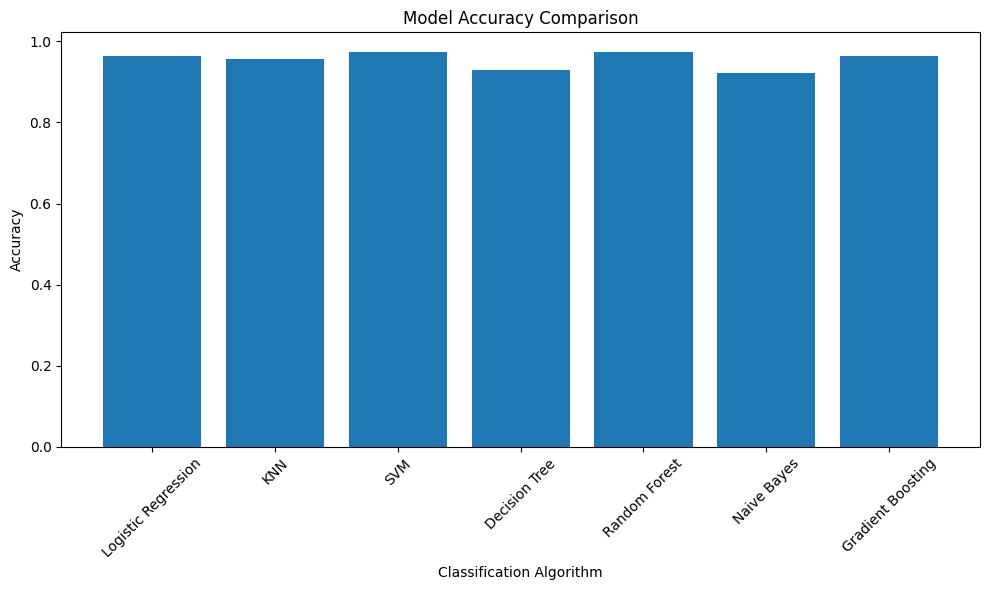

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xticks(rotation=45)

plt.xlabel("Classification Algorithm")
plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.tight_layout()

plt.show()

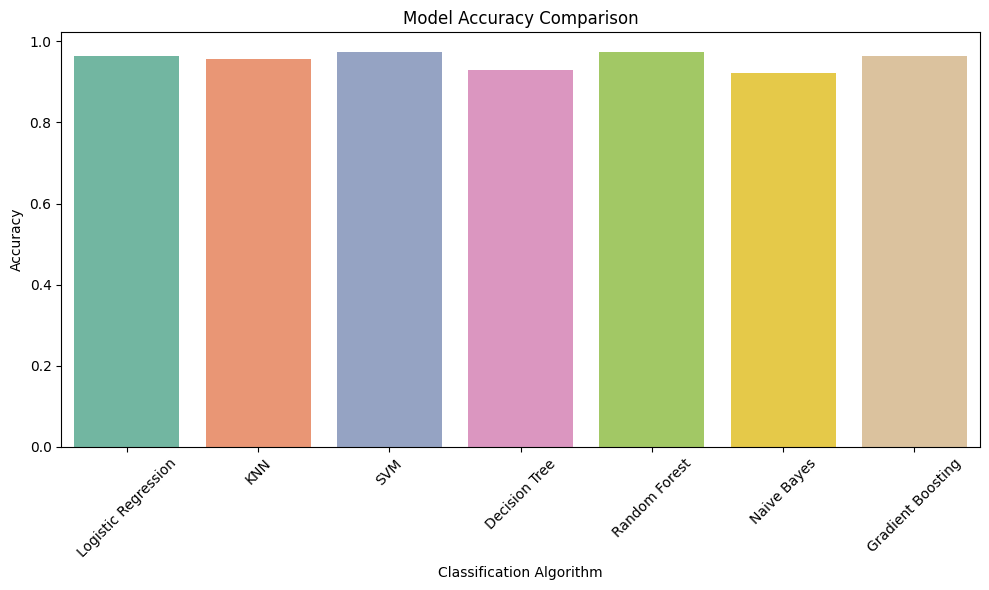

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="Set2",
    legend=False
)

plt.xticks(rotation=45)

plt.xlabel("Classification Algorithm")
plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.tight_layout()

plt.show()

In [33]:
model = LogisticRegression(max_iter=5000)

model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [36]:
y_pred = model.predict(X_test_scaled)

In [37]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [38]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[71  1]
 [ 3 39]]


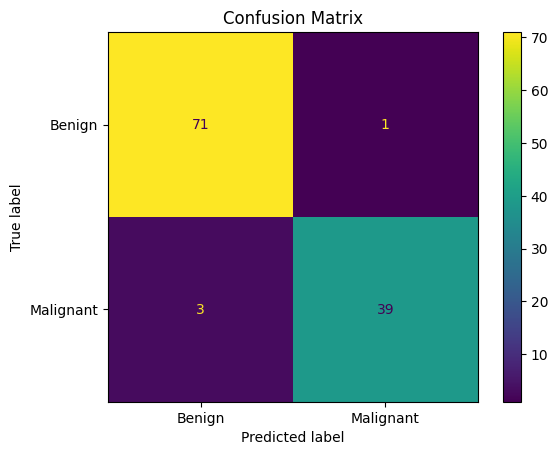

In [39]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [40]:
y_probability = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", auc)

ROC-AUC: 0.996031746031746


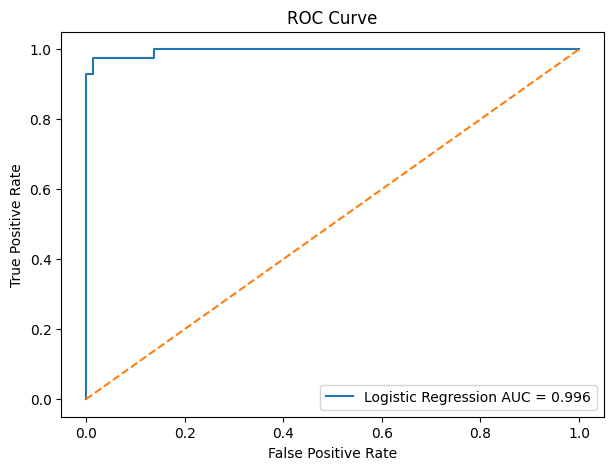

In [41]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [42]:
cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores:
[0.96703297 0.98901099 0.95604396 0.97802198 0.96703297]
Mean CV Accuracy: 0.9714285714285715


In [43]:
param_grid = {

    "C": [0.01, 0.1, 1, 10, 100],

    "solver": [
        "liblinear",
        "lbfgs"
    ]
}

In [44]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

In [45]:
grid_search.fit(
    X_train_scaled,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,LogisticRegre...max_iter=5000)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [46]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 0.1, 'solver': 'liblinear'}


In [47]:
print(
    "Best CV Accuracy:",
    grid_search.best_score_
)

Best CV Accuracy: 0.9736263736263737


In [48]:
best_model = grid_search.best_estimator_
best_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [49]:
y_pred = best_model.predict(X_test_scaled)

In [50]:
print(
    "Test Accuracy:",
    accuracy_score(y_test, y_pred)
)

Test Accuracy: 0.9824561403508771


In [51]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



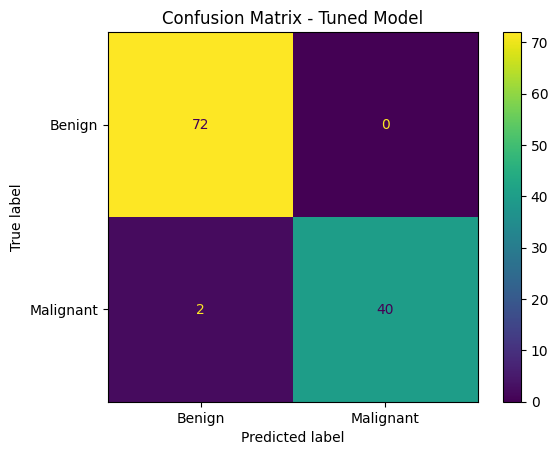

In [52]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("Confusion Matrix - Tuned Model")

plt.show()

In [53]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [54]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [55]:
rf_params = {

    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        None,
        5,
        10,
        15
    ],

    "min_samples_split": [
        2,
        5,
        10
    ]
}

In [56]:
rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),

    param_grid=rf_params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    verbose=1
)

In [57]:
rf_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [58]:
print(
    "Best Random Forest Parameters:"
)

print(
    rf_grid.best_params_
)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [59]:
logistic_accuracy = accuracy_score(
    y_test,
    best_model.predict(X_test_scaled)
)

rf_accuracy = accuracy_score(
    y_test,
    rf_grid.predict(X_test)
)

print(
    "Logistic Regression:",
    logistic_accuracy
)

print(
    "Random Forest:",
    rf_accuracy
)

Logistic Regression: 0.9824561403508771
Random Forest: 0.9736842105263158


In [60]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        rf_grid.best_estimator_.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
23,area_worst,0.151412
27,concave points_worst,0.126497
20,radius_worst,0.093475
22,perimeter_worst,0.083642
7,concave points_mean,0.081082
2,perimeter_mean,0.077126
0,radius_mean,0.061990
6,concavity_mean,0.050818
3,area_mean,0.045916
26,concavity_worst,0.030022


In [61]:
final_model = rf_grid.best_estimator_
final_model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
joblib.dump(
    final_model,
    "breast_cancer_model.pkl"
)

['breast_cancer_model.pkl']

In [63]:
joblib.dump(
    best_model,
    "breast_cancer_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [64]:
sample = X_test.iloc[0:1]

In [65]:
prediction = final_model.predict(sample)

print(prediction)

[0]


In [66]:
if prediction[0] == 1:
    print("Prediction: Malignant")
else:
    print("Prediction: Benign")

Prediction: Benign


In [67]:
probability = final_model.predict_proba(sample)

print(probability)

[[0.99 0.01]]
